<a href="https://colab.research.google.com/github/Faizantinwala007/AI-Cybersecurity-Threat-Detection/blob/main/AI_Cybersecurity_Threat_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**(1) MAIN TITLE **

# 🔐 AI-Powered Cybersecurity Threat Detection System

## 📌 Project Overview
This project detects cyber threats using Machine Learning by analyzing network activity and identifying anomalies.

(2) # IMPORTS

In [1]:
# Step 1: Import Libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

(3) # (CODE – DATASET)

In [2]:
# Step 2: Create Dataset

np.random.seed(42)

data_size = 300

login_attempts = np.random.randint(1, 50, data_size)
data_transfer = np.random.normal(300, 100, data_size)
session_time = np.random.normal(30, 10, data_size)

# Define attack condition
attack = (login_attempts > 30) | (data_transfer > 450) | (session_time > 50)
attack = attack.astype(int)

df = pd.DataFrame({
    "Login_Attempts": login_attempts,
    "Data_Transfer": data_transfer,
    "Session_Time": session_time,
    "Attack": attack
})

df.head()

,Login_Attempts,Data_Transfer,Session_Time,Attack
0,39,329.307247,24.697424,1
1,29,228.564858,22.071272,0
2,15,486.577451,28.929696,1
3,43,347.383292,19.647577,1
4,8,180.869650,24.463507,0


(4) # (MODEL TRAINING)

In [3]:
# Step 3: Train Model

X = df.drop("Attack", axis=1)
y = df["Attack"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

(5) # (CODE – PREDICTION)

In [4]:
# Step 4: Prediction & Evaluation

y_pred = model.predict(X_test)

print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Confusion Matrix:
 [[37  0]
 [ 2 21]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97        37
           1       1.00      0.91      0.95        23

    accuracy                           0.97        60
   macro avg       0.97      0.96      0.96        60
weighted avg       0.97      0.97      0.97        60



(6) # (CODE – VISUALIZATION)

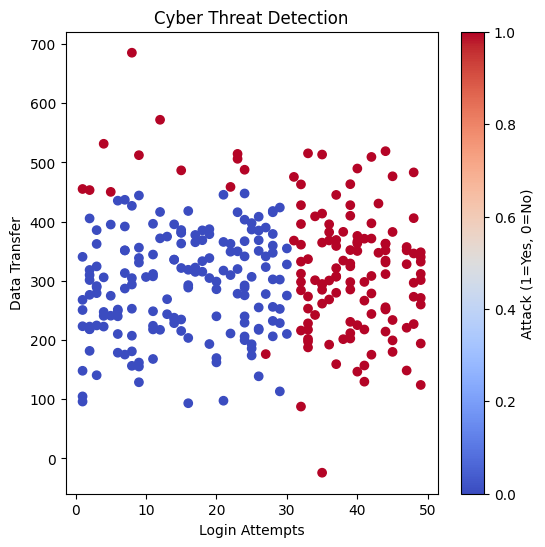

In [5]:
# Step 5: Visualization

plt.figure(figsize=(6,6))
plt.scatter(df["Login_Attempts"], df["Data_Transfer"], c=df["Attack"], cmap='coolwarm')

plt.xlabel("Login Attempts")
plt.ylabel("Data Transfer")
plt.title("Cyber Threat Detection")

plt.colorbar(label="Attack (1=Yes, 0=No)")
plt.show()